In [1]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt

# This
from numerics import *
from seismic import *

In [9]:
Mw = 6.3
site = Site(0., 0., 760., 0.5, 2.9, 1.)
erf1 = ERF(9., 5.)
erf2 = ERF(9., 4.,)
erf3 = ERF(12., 5.)
fault1 = Fault(0., 20., 3.0, 0.1, 40., 80., 90., 2.5, 0., erf1)
fault2 = Fault(0., 25., 0.5, 0.2, 80., 80., 30., 0.5, 1., erf2)
fault3 = Fault(22., 12.1, 1.4, 0.9, 130., 40., 22., 1.6, 0., erf3)
fault_tree = make_fault_tree(fault1, fault2, fault3)
scn = Scenario(site, fault_tree)

In [ ]:
import jax
from jax import lax
from jax import numpy as jnp
from jax import random as jrnd

import polars as pl 
from importlib.resources import files

from seismic.gm_utils import *

gmc = pl.read_csv(files("seismic") / "CY14_coeffs.csv")
gmc[-2, 'T'] = -1.
gmc[-1, 'T'] = -2.
gmc_col = gmc.columns
gmc = gmc.cast(pl.Float64).to_jax().T
T = gmc[0]
T_sort = jnp.argsort(T)
empty = jnp.zeros_like(T)

c_RB = gmc[4]
c_n, c_M, c_HM = gmc[jnp.array([12, 13, 16])]
c = jnp.empty((12, 5, T.shape[0]))
# c1, c1a - d
c = c.at[1].set(gmc[7:12])
# c2
c = c.at[2, 0].set(gmc[1])
# c3
c = c.at[3, 0].set(gmc[14])
# c4
c = c.at[4, 0:2].set(gmc[2:4])
# c5 - c7
c = c.at[5:8, 0].set(gmc[jnp.array([15, 17, 18])])
# c8
c = c.at[8, 0:3].set(gmc[jnp.array([5, 6, 20])])
# c9, c9a, c9b
c = c.at[9, 0:3].set(gmc[21:24])
# c11, c11b
c = c.at[11, jnp.array([0, 2])].set(gmc[24:26])
# c_gamma
c_gamma = jnp.insert(gmc[26:29], 0, empty, axis = 0)
phi = jnp.insert(gmc[29:35], 0, empty, axis = 0)
tau = jnp.insert(gmc[35:37], 0, empty, axis = 0)
sigma = jnp.insert(gmc[37:40], 0, empty, axis = 0)
sigma2_JP, gamma_JP_IT, gamma_WN = gmc[40:43]
phi1_JP, phi5_JP, phi6_JP = gmc[43:]

z_tor_const_RV = jnp.array([2.704, 1.226, 5.849])
z_tor_const_NM = jnp.array([2.673, 1.136, 4.97])

A = 571 ** 4
B = 1360 ** 4 + A

def f_SA_ref(Mw, dip, R_jb, R_rup, R_x, z_tor, SOF_flag):
    # Magnitude scaling
    r1 = c[1, 0] + c[2, 0] * (Mw - 6) + ((c[2, 0] - c[3, 0]) / c_n) * \
        jnp.log(1. + jnp.exp(c_n * (c_M - Mw)))
    # Near-field. magnitude + distance scaling
    r2 = c[4, 0] * jnp.log(R_rup + c[5, 0] * jnp.cosh(c[6, 0] * jnp.clip(Mw - c_HM, min = 0)))

    # Far-field distance scaling
    gamma = c_gamma[1] + c_gamma[2] / jnp.cosh(jnp.clip(Mw - c_gamma[3], min = 0))
    r3 = (c[4, 1] - c[4, 0]) * jnp.log((R_rup ** 2 + c_RB ** 2) ** (1 / 2)) + R_rup * gamma

    # Other source vars
    cosh_Mw = jnp.cosh(2 * jnp.clip(Mw - 4.5, min = 0))
    cos_dip = jnp.cos(jnp.deg2rad(dip))
    
    # Center zTor
    z_tor_const = lax.select(SOF_flag == -1., z_tor_const_RV, z_tor_const_NM)
    z_tor_Mw = jnp.clip(z_tor_const[0] - z_tor_const[1] * (Mw - z_tor_const[2]), min = 0, max = z_tor_const[0]) ** 2
    dz_tor = z_tor - z_tor_Mw
    c_SOF = lax.select(SOF_flag == -1., c[1, 1:4:2], c[1, 2:5:2]) * jnp.abs(SOF_flag)
    r4 = dz_tor * (c[7, 0] + c[7, 2] / cosh_Mw) + cos_dip ** 2 * (c[11, 0] + c[11, 2] / cosh_Mw) + c_SOF[0] + c_SOF[1] / cosh_Mw
    
    # Hanging wall
    r5 = c[9, 0] + cos_dip * \
        (c[9, 1] + (1 - c[9, 1]) * jnp.tanh(R_x / c[9, 2])) * \
        (1 - (R_jb ** 2 + z_tor ** 2) ** (1 / 2) / (R_rup + 1))
    r5 = jnp.where(R_x >= 0, r5, 0.)
    
    rsum = 0
    for i,rr in enumerate([r1, r2, r3, r4, r5]):
        rsum += rr
        plt.plot(T, rsum, label = i, ls = '--')

    return jnp.exp(r1 + r2 + r3 + r4 + r5)

def f_soil_nl(vs30):
    exp1 = jnp.exp(phi[3] * (jnp.clip(vs30, max = 1130) - 360))
    exp2 = jnp.exp(phi[3] * (1130 - 360))
    return phi[2] * (exp1 - exp2)

def f_lnSA(Mw, dip, z_tor, SOF_flag, 
           vs30, z1p0,
           R_jb, R_rup, R_x):
    soil_lin = phi[1] * jnp.clip(jnp.log(vs30 / 1130), max = 0)
    soil_nl = f_soil_nl(vs30)
    SA_ref = f_SA_ref(Mw, dip,
                      R_jb, R_rup, R_x,
                      z_tor, SOF_flag)
    soil_nl_mod = soil_nl * jnp.log((SA_ref + phi[4]) / phi[4])
    z1_ref = jnp.exp(-7.15 / 4 * jnp.log((vs30 ** 4 + A) / B))
    dz1 = (z1p0 * 1000) - z1_ref
    rk_depth = phi[5] * (1 - jnp.exp(- dz1 / phi[6]))

    lnSA = jnp.log(SA_ref) + soil_lin + soil_nl_mod + rk_depth
    return lnSA, soil_nl, SA_ref

def f_sigma(Mw, vs30inf_flag, soil_nl, SA_ref):
    nl0 = soil_nl * SA_ref / (SA_ref + phi[4])
    nl0sq = (1 + nl0) ** 2
    Mw_test = jnp.clip(Mw - 5., min = 0, max = 1.5)
    tau_test = tau[1] + (tau[2] - tau[1]) / 1.5 * Mw_test

    vs30inf = lax.select(vs30inf_flag == 1., sigma[3], jnp.full_like(T, 0.7))
    sig_nl0 = sigma[1] + (sigma[2] - sigma[1]) / 1.5 * Mw_test
    sig_nl0 = sig_nl0 * (vs30inf + nl0sq) ** (1 / 2)

    return (tau_test ** 2 * nl0sq + sig_nl0 ** 2)

def f_CY14(Mw:float, site:Site, fault:Fault):
    R_jb = calc_R_jb(site, fault)
    R_rup = calc_R_rup(site, fault)
    R_x = calc_R_x(site, fault)
    SOF_flag = fault.calc_SOF_flag()
    lnSA, soil_nl, SA_ref = f_lnSA(Mw, fault.dip, fault.z_tor, SOF_flag, site.vs30, site.z1p0, R_jb, R_rup, R_x)
    std = f_sigma(Mw, site.vs30inf_flag, soil_nl, SA_ref)
    lnSA = jnp.interp(T_master, T[T_sort], lnSA[T_sort])
    std = jnp.interp(T_master, T[T_sort], std[T_sort])
    return lnSA, std

{'name': 'Deterministic Response Spectra', 'date': '2025-11-19T00:23:52Z', 'status': 'success', 'url': '/spectra', 'request': {'gmms': ['CY_14'], 'input': {'Mw': 6.3, 'rJB': 12.874347532316035, 'rRup': 12.905342075494785, 'rX': 12.905342075494785, 'dip': 40.0, 'width': 1.6, 'zTor': 0.5, 'zHyp': 7.5, 'rake': 22.0, 'vs30': 760.0, 'z1p0': 0.5, 'z2p5': 2.9, 'zSed': None}}, 'response': {'means': {'label': 'Means', 'xLabel': 'Period (s)', 'yLabel': 'Median ground motion (g)', 'data': [{'id': 'CY_14', 'label': 'Chiou & Youngs (2014)', 'data': {'pga': 0.15574, 'pgv': 11.082, 'sa': {'xs': [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0], 'ys': [0.15574, 0.15815, 0.1791, 0.24102, 0.31497, 0.35516, 0.38258, 0.36752, 0.33563, 0.30235, 0.24575, 0.20408, 0.13635, 0.097183, 0.058797, 0.040386, 0.022118, 0.013089, 0.0082068, 0.0034013, 0.0017647]}}, 'tree': [{'id': 'epi-lo', 'values': {'pga': 0.12254, 'pgv': 8.7195, 'sa': [0.12254, 0.1

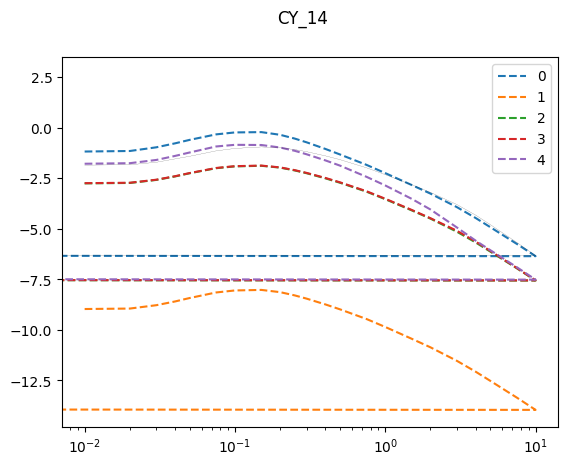

In [22]:
my_T = T_master
import requests
test_site = site
test_fault = fault3
def test_model(name, model):
    my_lnSA, my_sigma = model(Mw, test_site, test_fault)

    # API
    url_base = 'https://earthquake.usgs.gov/ws/nshmp/gmm/spectra?'
    R_jb = calc_R_jb(site, fault1)
    R_rup = calc_R_rup(site, fault1)
    R_x = calc_R_x(site, fault1)

    url_inputs = (name, Mw, R_jb, R_rup, R_x, test_fault.dip, test_fault.width, test_fault.z_tor, test_fault.z_hyp, test_fault.rake, test_site.vs30, test_site.z1p0, test_site.z2p5)
    url_addn = 'gmm=%s&Mw=%s&rJB=%s&rRup=%s&rX=%s&dip=%s&width=%s&z_tor=%s&z_hyp=%s&rake=%s&vs30=%s&z1p0=%s&z2p5=%s'%url_inputs
    json = requests.get(url_base + url_addn).json()
    print(json)
    api_T = json['response']['means']['data'][0]['data']['sa']['xs']
    api_PGA, api_PGV = [json['response']['means']['data'][0]['data'][key] for key in ['pga', 'pgv']]
    if api_PGV is None:
        api_PGV = jnp.nan
    api_SA = json['response']['means']['data'][0]['data']['sa']['ys']
    api_T, api_SA= [jnp.array(_) for _ in [api_T, api_SA]]
    api_T = jnp.append(api_T, jnp.array([-1, -2]))
    api_SA = jnp.append(api_SA, jnp.array([api_PGA, api_PGV]))
    api_lnSA = jnp.log(api_SA)

    plt.plot(api_T, api_lnSA, c = 'k', lw = 0.1)
    #plt.plot(my_T, my_lnSA, c = 'r', ls = '--')
    plt.xscale('log')
    plt.legend()
    plt.suptitle(name)
    plt.show()

for n,m in zip(['CY_14'], [f_CY14]):
    test_model(n,m)

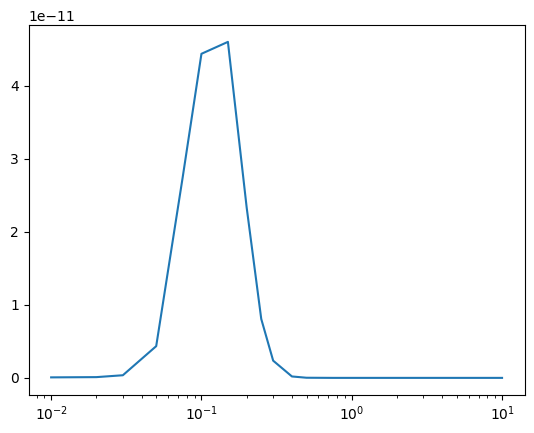

In [ ]:
from jax.scipy.stats.norm import cdf as gaussian_cdf

@jtu.register_pytree_node_class
class GMMLT:
    def __init__(self, gmms:list, weights:jax.typing.ArrayLike):
        self.gmms = gmms
        self.weights = weights

    def calc_all(self, Mw:float, site:Site, fault:Fault):
        gmm_idcs = jnp.arange(self.weights.shape[0])
        def apply(Mw, site, fault, gmm_idx):
            return lax.switch(gmm_idx, self.gmms, Mw, site, fault)
        all_lnSA, all_std = jax.vmap(jtu.Partial(apply, Mw, site, fault))(gmm_idcs)
        return all_lnSA, all_std
    
    def calc_mean(self, Mw:float, site:Site, fault:Fault):
        all_lnSA, all_std = self.calc_all(Mw, site, fault)
        mean_lnSA = jnp.einsum('i,ij->j', self.weights, all_lnSA)
        mean_std = jnp.einsum('i,ij->j', self.weights, all_std)
        return mean_lnSA, mean_std

    def tree_flatten(self):
        return (self.weights), self.gmms
    
    @classmethod
    def tree_unflatten(cls, aux, children):
        return cls(aux, *children)

def calc_haz(IM:float, M_min:float, gmms:GMMLT, scn:Scenario, n:int = 30):
    # roots + weights for magnitude integral
    M_min, M_max = test_fault.erf.M_min, test_fault.erf.M_max
    roots_M, weights_M = jax.vmap(mvrw_sobol, in_axes = [None, 0, 0, None])(1, M_min, M_max, n)
    # Indexing for vmap (redundant, fix)
    fault_num = test_fault.x.shape[0]
    fault_n_idcs = jnp.arange(fault_num)
    # ERF incremental rates for Legendre roots
    n_M = jax.vmap(test_fault.erf.calc_n)(roots_M)
    n_M = n_M[fault_n_idcs, :, fault_n_idcs]
    # Ground motion means + stds for each fault at Legendre roots
    mu_lnSA, std_lnSA = jax.vmap(jax.vmap(gmms.calc_mean, in_axes = (0, None, None)), in_axes = (0, None, 0))(roots_M, site, test_fault)
    # Probabilities of exceedance 
    prob_IM = 1 - gaussian_cdf(jnp.log(IM), mu_lnSA, std_lnSA)
    # Hazard integrand (magnitude probabilities * exceedance probabilities)
    haz_intgrnd = n_M[:, :, None] * prob_IM
    # Integrate using mag weights
    haz_intgrl = jnp.einsum('ij,ijk->ik', weights_M, haz_intgrnd)
    haz = haz_intgrl.sum(axis = 0)
    return haz

def calc_marginal_haz(IM:float, M_min:float, gmms:GMMLT, scn:Scenario, n:int = 30):
    pass 
    

    """
    For each source: 
    Grab N_k (rate of earthquakes exceeding minimum magnitude)
    Integrate pdf of magnitude (from ERF?) * IM (from GMM) over magnitude
    
    Marginal hazard for a single scenario is:
    N_k * f_m(M) * f_r(R|M)*P(Y>IM|M,R)
    Where I'm assuming that f_r will be one for a point source...
    """

IM = 0.3
Mw_min = 4.
gmm_backbones = [f_ASK14, f_BSSA14, f_CB14, f_CY14, f_Idriss14]
gmm_epi_plus = []#[f_epistemic_AAY14(gmm, 3.18) for gmm in gmm_backbones]
gmm_epi_minus = []#[f_epistemic_AAY14(gmm, -3.18) for gmm in gmm_backbones]
gmms = gmm_backbones + gmm_epi_plus + gmm_epi_minus
weights = jnp.ones(len(gmms)) / len(gmms)
gmmlt = GMMLT(gmms, weights)
haz = calc_haz(IM, Mw_min, gmmlt, scn)

plt.plot(T_master, haz)
plt.xscale('log')